# Rebuttal Scatter Plot

This notebook repeats the hidden-state regression experiment with a configurable linear architecture.

- Set `hidden_dims = [n]` to recover the original two-layer model.
- Set `hidden_dims = [n, n, n]` or any other list to add more hidden linear layers.
- Each hidden layer is regressed onto the Kalman filter state, and the notebook reports per-coordinate R-squared tables so different hidden dimensions remain comparable.


In [1]:
import sys
from pathlib import Path

project_root = next((path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'exp').exists()), None)
if project_root is None:
    raise RuntimeError("Could not find project root containing 'exp'.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from IPython.display import Markdown, display
from torch.optim.lr_scheduler import StepLR

from exp.ARmodel import MultiLayerLinearAR
from exp.dataloader import make_dataset
from exp.define_system import define_system
from exp.simulate import simulate
from exp.steady_state_KF import run_steady_state_kalman_filter


In [2]:
n, p, m = 4, 2, 3
rho_target = 1.0
sys_seed = 0

L = 10
horizons = [1, 5]
hidden_dims = [n, 2*n, 3*n]  # Use [n] to recover the original two-layer model.
plot_state_index = 1  # Coordinate shown in the scatter plot.

train_T = 10000
test_T = 1000
epochs = 150
batch_size = 64
lr = 0.05
step_size = 2
gamma = 0.9
weight_decay = 1e-3

train_seed = 10
torch_seed = 20
test_seed = 30
test_umode = 'ramp_sine'
dist_type = 'gaussian'

A, B, C = define_system(n, p, m, rho_target, seed=sys_seed)
W = 0.05 * np.eye(n)
V = 0.1 * np.eye(m)


Spectral radius of A:  1.0000000000000007
Observable? True (rank 4 of 4)
Controllable? True (rank 4 of 4)


In [3]:
def simulate_kalman_trajectory(
    A,
    B,
    C,
    W,
    V,
    T,
    *,
    seed,
    u_mode=None,
    u_scale=1.0,
    period=50,
    dist_type='gaussian',
):
    n = A.shape[0]
    _, Y, U = simulate(
        A,
        B,
        C,
        W,
        V,
        T,
        seed=seed,
        u_mode=u_mode,
        u_scale=u_scale,
        period=period,
        dist_type=dist_type,
    )
    kf_pred_x, _ = run_steady_state_kalman_filter(A, B, C, W, V, np.zeros(n), U, Y)
    return Y, U, kf_pred_x


def compute_coordinate_r2(true_states, predicted_states):
    residual_ss = np.sum((true_states - predicted_states) ** 2, axis=0)
    centered_true_states = true_states - true_states.mean(axis=0, keepdims=True)
    total_ss = np.sum(centered_true_states ** 2, axis=0)

    coordinate_r2 = np.full(true_states.shape[1], np.nan)
    valid = total_ss > 0
    coordinate_r2[valid] = 1.0 - residual_ss[valid] / total_ss[valid]
    return coordinate_r2


def train_configurable_scatter(
    A,
    B,
    C,
    W,
    V,
    *,
    L,
    H,
    hidden_dims,
    train_T,
    test_T,
    epochs,
    batch_size,
    lr,
    step_size,
    gamma,
    weight_decay,
    train_seed,
    torch_seed,
    test_seed,
    test_umode,
    dist_type,
):
    n = A.shape[0]
    p = B.shape[1]
    m = C.shape[0]

    train_Y, train_U, train_kf_x = simulate_kalman_trajectory(
        A,
        B,
        C,
        W,
        V,
        train_T + H,
        seed=train_seed,
        dist_type=dist_type,
    )
    train_loader, _, _, _ = make_dataset(
        L,
        H,
        train_Y,
        train_U,
        train_kf_x,
        batch_size=batch_size,
    )

    torch.manual_seed(torch_seed)
    model = MultiLayerLinearAR((m + p) * L, hidden_dims, m * H)

    criterion = nn.MSELoss(reduction='sum')
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = StepLR(optimizer, step_size=step_size, gamma=gamma)

    losses = []
    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for batch_inputs, batch_outputs in train_loader:
            outputs, _ = model(batch_inputs)
            loss = criterion(outputs, batch_outputs)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        average_loss = total_loss / len(train_loader.dataset)
        losses.append(average_loss)
        print(
            f'Epoch [{epoch + 1}/{epochs}], Training Loss: {average_loss:.4f}, '
            f'Learning Rate: {optimizer.param_groups[0]["lr"]:.6f}'
        )
        scheduler.step()

    model.eval()
    test_Y, test_U, test_kf_x = simulate_kalman_trajectory(
        A,
        B,
        C,
        W,
        V,
        test_T + H,
        seed=test_seed,
        u_mode=test_umode,
        u_scale=2.0,
        period=40,
        dist_type=dist_type,
    )
    _, test_inputs_np, _, test_kf_states_np = make_dataset(
        L,
        H,
        test_Y,
        test_U,
        test_kf_x,
        batch_size=batch_size,
    )

    with torch.no_grad():
        test_inputs_tensor = torch.tensor(test_inputs_np, dtype=torch.float32)
        _, hidden_activations = model(test_inputs_tensor)

    layer_results = []
    for layer_index, activation in enumerate(hidden_activations, start=1):
        activation_np = activation.detach().cpu().numpy()
        coeff, _, _, _ = np.linalg.lstsq(activation_np, test_kf_states_np, rcond=None)
        predicted_states = activation_np @ coeff
        coeff_rank = int(np.linalg.matrix_rank(coeff))
        coordinate_r2 = compute_coordinate_r2(test_kf_states_np, predicted_states)

        layer_results.append(
            {
                'layer_index': layer_index,
                'hidden_dim': activation_np.shape[1],
                'activations': activation_np,
                'predicted_states': predicted_states,
                'coeff_rank': coeff_rank,
                'coordinate_r2': coordinate_r2,
            }
        )
        print(
            f'Layer {layer_index} coefficient rank: {coeff_rank}, '
            f'mean R^2: {np.nanmean(coordinate_r2):.4f}'
        )

    return {
        'model': model,
        'kf_states': test_kf_states_np,
        'layer_results': layer_results,
        'losses': losses,
    }


def plot_loss_curves(results_by_horizon):
    plt.figure(figsize=(8, 4))
    for H, result in results_by_horizon.items():
        plt.plot(result['losses'], label=f'H={H}')
    plt.xlabel('Epoch')
    plt.ylabel('Training Loss')
    plt.title(f'Training Losses for hidden_dims={hidden_dims}')
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_scatter_grid(results_by_horizon, *, state_index, save_dir):
    assert 0 <= state_index < n
    horizon_items = list(results_by_horizon.items())
    num_rows = len(horizon_items)
    num_cols = max(len(result['layer_results']) for _, result in horizon_items)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4.5 * num_rows), squeeze=False)

    for row, (H, result) in enumerate(horizon_items):
        x_kf = result['kf_states'][:, state_index]
        for col in range(num_cols):
            ax = axes[row][col]
            if col >= len(result['layer_results']):
                ax.axis('off')
                continue

            layer_result = result['layer_results'][col]
            x_act = layer_result['predicted_states'][:, state_index]
            coord_r2 = layer_result['coordinate_r2'][state_index]
            ax.scatter(
                x_kf,
                x_act,
                s=10,
                alpha=0.6,
                label=(
                    f'H={H}, layer {layer_result["layer_index"]}, '
                    f'd={layer_result["hidden_dim"]}, R^2={coord_r2:.3f}'
                ),
            )

            vmin = min(np.min(x_kf), np.min(x_act))
            vmax = max(np.max(x_kf), np.max(x_act))
            ax.plot([vmin, vmax], [vmin, vmax], linestyle='--', linewidth=1)
            ax.set_title(f'H={H}, layer {layer_result["layer_index"]}')
            ax.set_xlabel(f'Kalman Filter State {state_index}', fontsize=12)
            ax.set_ylabel(f'Regressed Hidden State {state_index}', fontsize=12)
            ax.grid(True)
            ax.legend(fontsize=10)

    fig.tight_layout()
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    architecture_tag = '-'.join(str(dim) for dim in hidden_dims)
    figure_path = save_dir / f'rebuttal_scatter_state{state_index}_layers{architecture_tag}.png'
    fig.savefig(figure_path, dpi=600, bbox_inches='tight')
    plt.show()
    return figure_path


def make_r2_tables(results_by_horizon):
    horizon_items = sorted(results_by_horizon.items())
    num_layers = max(len(result['layer_results']) for _, result in horizon_items)
    r2_tables = {}

    for layer_offset in range(num_layers):
        rows = []
        for H, result in horizon_items:
            layer_result = result['layer_results'][layer_offset]
            row = {
                'horizon': H,
                'hidden_dim': layer_result['hidden_dim'],
                'coeff_rank': layer_result['coeff_rank'],
            }
            for coord_index, score in enumerate(layer_result['coordinate_r2']):
                row[f'state_{coord_index}_r2'] = score
            row['mean_r2'] = np.nanmean(layer_result['coordinate_r2'])
            rows.append(row)

        r2_tables[layer_offset + 1] = pd.DataFrame(rows).set_index('horizon')

    return r2_tables


def display_r2_tables(r2_tables, *, precision=4):
    for layer_index, table in r2_tables.items():
        hidden_dim = int(table['hidden_dim'].iloc[0])
        display(Markdown(f'### Hidden Layer {layer_index} (dim={hidden_dim})'))
        display(table.round(precision))


In [4]:
results_by_horizon = {}
for H in horizons:
    print(f'Running H={H} with hidden_dims={hidden_dims}')
    results_by_horizon[H] = train_configurable_scatter(
        A,
        B,
        C,
        W,
        V,
        L=L,
        H=H,
        hidden_dims=hidden_dims,
        train_T=train_T,
        test_T=test_T,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        step_size=step_size,
        gamma=gamma,
        weight_decay=weight_decay,
        train_seed=train_seed,
        torch_seed=torch_seed,
        test_seed=test_seed,
        test_umode=test_umode,
        dist_type=dist_type,
    )

Running H=1 with hidden_dims=[4, 8, 12]
Epoch [1/150], Training Loss: 337.4651, Learning Rate: 0.050000
Epoch [2/150], Training Loss: 1.8399, Learning Rate: 0.050000
Epoch [3/150], Training Loss: 2.2810, Learning Rate: 0.045000
Epoch [4/150], Training Loss: 2.0606, Learning Rate: 0.045000
Epoch [5/150], Training Loss: 1.1513, Learning Rate: 0.040500
Epoch [6/150], Training Loss: 1.0468, Learning Rate: 0.040500
Epoch [7/150], Training Loss: 1.0037, Learning Rate: 0.036450
Epoch [8/150], Training Loss: 1.0349, Learning Rate: 0.036450
Epoch [9/150], Training Loss: 0.9058, Learning Rate: 0.032805
Epoch [10/150], Training Loss: 1.3532, Learning Rate: 0.032805
Epoch [11/150], Training Loss: 0.9112, Learning Rate: 0.029525
Epoch [12/150], Training Loss: 0.9142, Learning Rate: 0.029525
Epoch [13/150], Training Loss: 0.8849, Learning Rate: 0.026572
Epoch [14/150], Training Loss: 0.8784, Learning Rate: 0.026572
Epoch [15/150], Training Loss: 0.8863, Learning Rate: 0.023915
Epoch [16/150], Traini

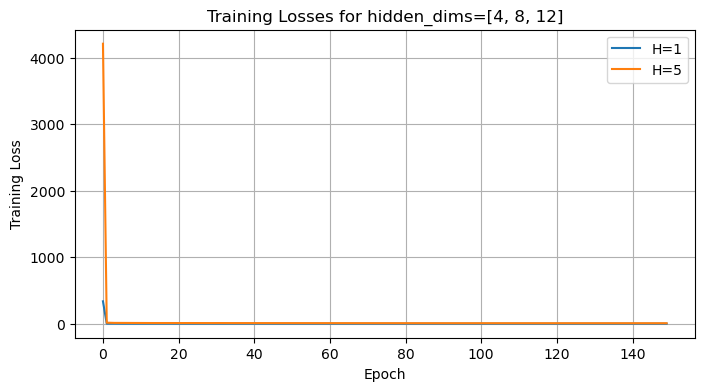

In [5]:
plot_loss_curves(results_by_horizon)

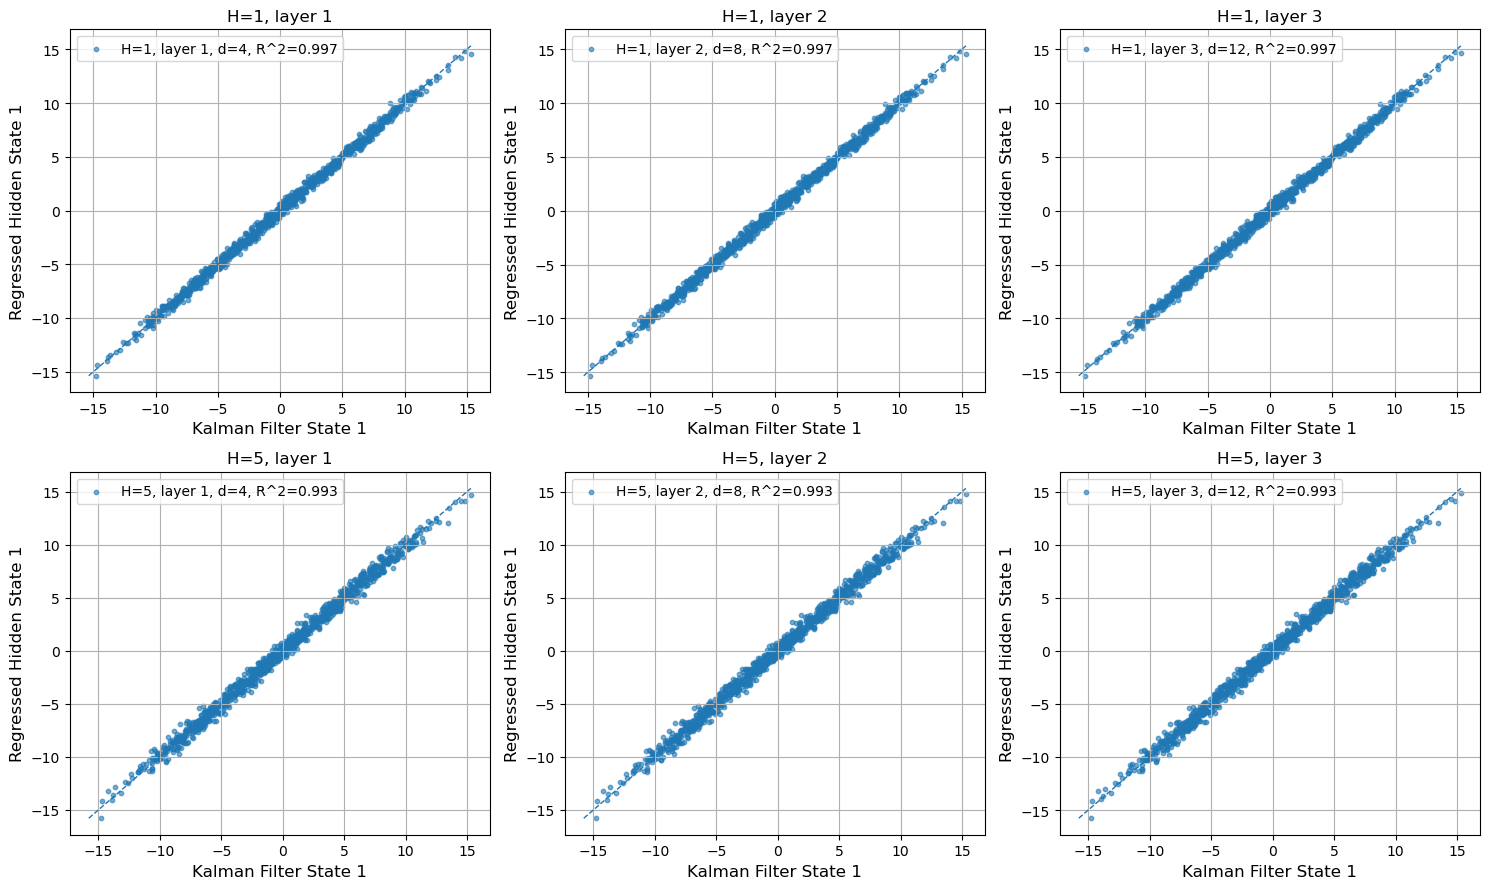

Saved scatter plot to figs/rebuttal_scatter_state1_layers4-8-12.png


### Hidden Layer 1 (dim=4)

,hidden_dim,coeff_rank,state_0_r2,state_1_r2,state_2_r2,state_3_r2,mean_r2
horizon,,,,,,,
1,4,4,0.9977,0.9968,0.9991,0.9989,0.9981
5,4,4,0.9891,0.9933,0.9976,0.9966,0.9941


### Hidden Layer 2 (dim=8)

,hidden_dim,coeff_rank,state_0_r2,state_1_r2,state_2_r2,state_3_r2,mean_r2
horizon,,,,,,,
1,8,4,0.9977,0.9968,0.9991,0.9989,0.9981
5,8,4,0.9891,0.9933,0.9976,0.9966,0.9942


### Hidden Layer 3 (dim=12)

,hidden_dim,coeff_rank,state_0_r2,state_1_r2,state_2_r2,state_3_r2,mean_r2
horizon,,,,,,,
1,12,4,0.9977,0.9969,0.9991,0.9989,0.9982
5,12,4,0.9892,0.9933,0.9977,0.9966,0.9942


In [6]:
figure_path = plot_scatter_grid(
    results_by_horizon,
    state_index=plot_state_index,
    save_dir=Path('figs'),
)
print(f'Saved scatter plot to {figure_path}')

r2_tables = make_r2_tables(results_by_horizon)
display_r2_tables(r2_tables)
